# MobileNetV3-Small + Grad-CAM + Heatmap-Based Cropping

This notebook shows a minimal, modular pipeline for:
1. Quick training (3 epochs) on the under-sampled + augmented WCE dataset.
2. Grad-CAM visualization using the last convolutional layer of MobileNetV3-Small.
3. Heatmap-threshold-based cropping of most activated region.
4. Prediction comparison between original and cropped images.

In [1]:
import os
import random
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# -----------------------------
# Configuration
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

DATA_DIR = './working/augmented'  # Under-sampled + augmented data from your previous pipeline
IMG_SIZE = 224
BATCH_SIZE = 16
QUICK_EPOCHS = 3
NUM_WORKERS = 0 if os.name == 'nt' else 2

CHECKPOINT_PATH = './results/mobilenetv3_small_gradcam_quick.pth'
OUTPUT_DIR = './results/gradcam_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

to_pil = transforms.ToPILImage()

Using device: cuda


In [2]:
# -----------------------------
# Dataset utilities
# -----------------------------
class SimpleImageDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples  # list of (path, label)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label


def build_class_mapping(root_dir):
    classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {name: i for i, name in enumerate(classes)}
    idx_to_class = {i: name for name, i in class_to_idx.items()}
    return class_to_idx, idx_to_class


def collect_samples(root_dir, class_to_idx):
    out = []
    exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    for cls_name in sorted(class_to_idx.keys()):
        cls_dir = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        label = class_to_idx[cls_name]
        for fn in os.listdir(cls_dir):
            if fn.lower().endswith(exts):
                out.append((os.path.join(cls_dir, fn), label))
    return out


def stratified_split(samples, test_ratio=0.2, seed=42):
    by_label = defaultdict(list)
    for s in samples:
        by_label[s[1]].append(s)

    rng = random.Random(seed)
    train_samples, test_samples = [], []
    for label, arr in by_label.items():
        rng.shuffle(arr)
        n_test = max(1, int(len(arr) * test_ratio))
        test_samples.extend(arr[:n_test])
        train_samples.extend(arr[n_test:])

    rng.shuffle(train_samples)
    rng.shuffle(test_samples)
    return train_samples, test_samples


class_to_idx, idx_to_class = build_class_mapping(DATA_DIR)
all_samples = collect_samples(DATA_DIR, class_to_idx)
train_samples, test_samples = stratified_split(all_samples, test_ratio=0.2, seed=SEED)

train_ds = SimpleImageDataset(train_samples, train_tf)
test_ds = SimpleImageDataset(test_samples, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

num_classes = len(class_to_idx)
print(f'Classes: {num_classes}')
print(f'Train samples: {len(train_ds)} | Test samples: {len(test_ds)}')

Classes: 14
Train samples: 2240 | Test samples: 560


In [3]:
# -----------------------------
# Model + quick training
# -----------------------------
def build_mobilenet_v3_small(num_classes):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

    # Freeze early layers for fast fine-tuning
    params = list(model.features.parameters())
    freeze_count = int(0.8 * len(params))
    for p in params[:freeze_count]:
        p.requires_grad = False

    in_features = model.classifier[0].in_features  # 576 for MobileNetV3-Small
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


@torch.no_grad()
def evaluate_accuracy(model, loader, device):
    model.eval()
    total, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / max(1, total)


def quick_train(model, train_loader, test_loader, device, epochs=2, lr=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)

        train_loss = running_loss / max(1, total)
        test_acc = evaluate_accuracy(model, test_loader, device)
        print(f'Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.4f}')

    return model


model = build_mobilenet_v3_small(num_classes)

if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    print(f'Loaded trained weights from: {CHECKPOINT_PATH}')
else:
    print('No checkpoint found. Running quick training...')
    model = quick_train(model, train_loader, test_loader, DEVICE, epochs=QUICK_EPOCHS, lr=1e-3)
    os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
    torch.save(model.state_dict(), CHECKPOINT_PATH)
    print(f'Saved checkpoint to: {CHECKPOINT_PATH}')

model.eval()

No checkpoint found. Running quick training...
Epoch 1/3 | Train Loss: 1.3435 | Test Acc: 0.6679
Epoch 2/3 | Train Loss: 0.6319 | Test Acc: 0.7839
Epoch 3/3 | Train Loss: 0.4787 | Test Acc: 0.8589
Saved checkpoint to: ./results/mobilenetv3_small_gradcam_quick.pth


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [4]:
# -----------------------------
# Grad-CAM implementation
# -----------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.h1 = self.target_layer.register_forward_hook(self._forward_hook)
        self.h2 = self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam[0, 0].cpu().numpy()

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam, class_idx

    def remove_hooks(self):
        self.h1.remove()
        self.h2.remove()


def denormalize_tensor(x):
    """Convert normalized CHW tensor to displayable HWC array [0, 1]."""
    mean = torch.tensor(IMAGENET_MEAN, device=x.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=x.device).view(3, 1, 1)
    y = x * std + mean
    y = y.clamp(0, 1)
    return y.permute(1, 2, 0).cpu().numpy()


@torch.no_grad()
def predict_with_confidence(model, input_tensor, idx_to_class):
    model.eval()
    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1)
    conf, pred_idx = probs.max(dim=1)
    return idx_to_class[int(pred_idx.item())], float(conf.item()), int(pred_idx.item())


def make_overlay(image_rgb, heatmap, alpha=0.45):
    """Overlay Grad-CAM heatmap on RGB image. image_rgb must be HxWx3 in [0,1]."""
    cmap = plt.get_cmap('jet')
    heat_rgb = cmap(heatmap)[..., :3]
    overlay = (1 - alpha) * image_rgb + alpha * heat_rgb
    return np.clip(overlay, 0, 1)


target_layer = model.features[-1]  # last convolutional block in MobileNetV3-Small
grad_cam = GradCAM(model, target_layer)

In [5]:
# -----------------------------
# Heatmap-based cropping utilities
# -----------------------------
def largest_connected_component(mask):
    """Return boolean mask for the largest 4-connected component."""
    h, w = mask.shape
    visited = np.zeros_like(mask, dtype=bool)
    best_coords = []

    for r in range(h):
        for c in range(w):
            if not mask[r, c] or visited[r, c]:
                continue

            stack = [(r, c)]
            visited[r, c] = True
            coords = []

            while stack:
                x, y = stack.pop()
                coords.append((x, y))
                for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < h and 0 <= ny < w and mask[nx, ny] and not visited[nx, ny]:
                        visited[nx, ny] = True
                        stack.append((nx, ny))

            if len(coords) > len(best_coords):
                best_coords = coords

    out = np.zeros_like(mask, dtype=bool)
    if best_coords:
        rr, cc = zip(*best_coords)
        out[np.array(rr), np.array(cc)] = True
    return out


def bbox_from_mask(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return (0, 0, IMG_SIZE - 1, IMG_SIZE - 1)
    return (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max()))


def crop_from_heatmap(pil_image_224, heatmap, top_fraction=0.30):
    """
    1) keep top `top_fraction` activations,
    2) find largest activated component,
    3) crop bbox,
    4) resize back to 224x224.
    """
    threshold = float(np.quantile(heatmap, 1.0 - top_fraction))
    binary_mask = heatmap >= threshold

    lcc_mask = largest_connected_component(binary_mask)
    x1, y1, x2, y2 = bbox_from_mask(lcc_mask)

    # PIL crop uses (left, top, right, bottom) with right/bottom exclusive
    cropped = pil_image_224.crop((x1, y1, x2 + 1, y2 + 1)).resize((IMG_SIZE, IMG_SIZE))

    stats = {
        'threshold': threshold,
        'mask_pixels_top_fraction': int(binary_mask.sum()),
        'mask_pixels_lcc': int(lcc_mask.sum()),
        'bbox': (x1, y1, x2, y2),
        'bbox_width': int(x2 - x1 + 1),
        'bbox_height': int(y2 - y1 + 1),
    }
    return cropped, lcc_mask, stats

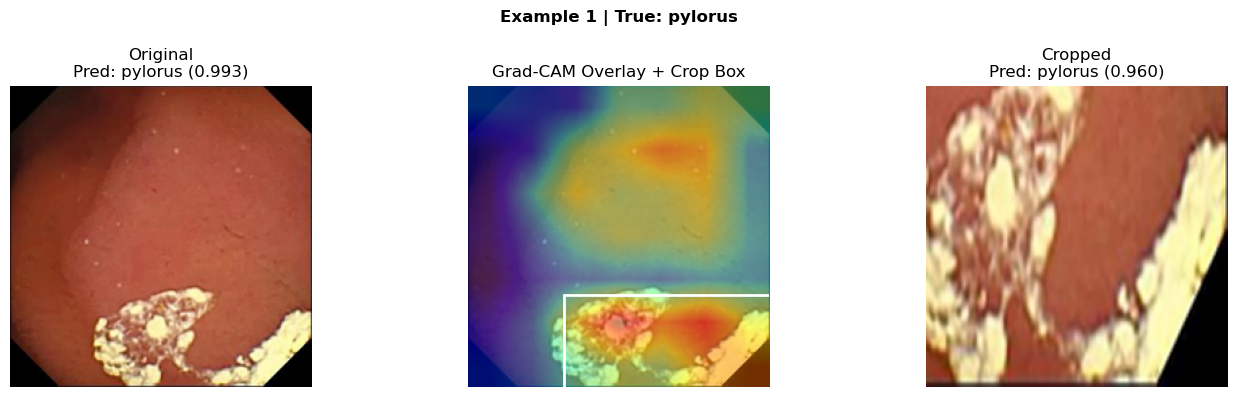

[1] 0531325b64674948_3557.jpg
  Original -> class: pylorus                   | confidence: 0.9928
  Cropped  -> class: pylorus                   | confidence: 0.9598
  Heatmap shape: (224, 224) | min/max: (0.0000, 1.0000)
  Threshold (top 30%): 0.5383
  BBox (x1,y1,x2,y2): (71, 155, 223, 223) | size: 153x69
  Largest component area ratio: 0.1610
  Saved: 01_0531325b64674948_3557_original.png, _heatmap.png, _overlay.png, _cropped.png, _details.txt
----------------------------------------------------------------------------------------------------


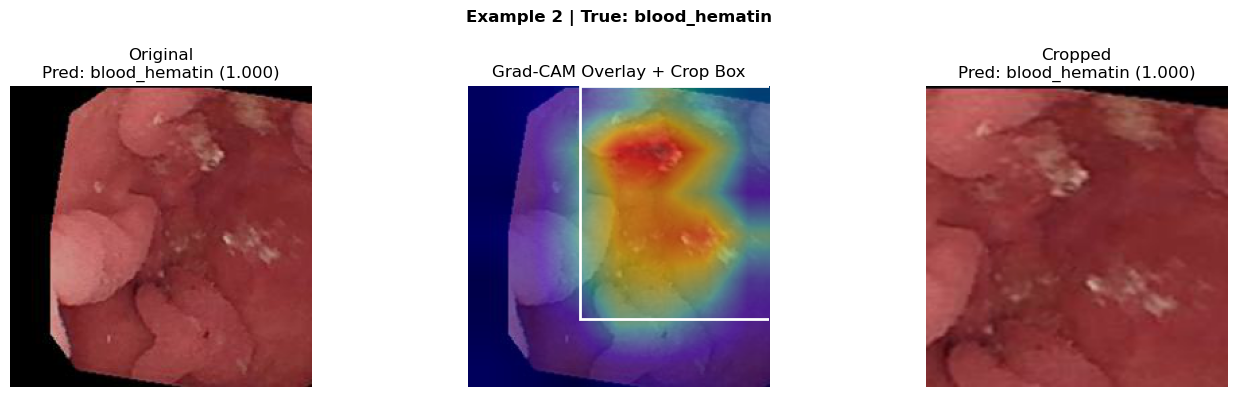

[2] aug_147_8ebf0e483cac48d6_1211.jpg
  Original -> class: blood_hematin             | confidence: 1.0000
  Cropped  -> class: blood_hematin             | confidence: 1.0000
  Heatmap shape: (224, 224) | min/max: (0.0000, 1.0000)
  Threshold (top 30%): 0.4268
  BBox (x1,y1,x2,y2): (83, 0, 223, 172) | size: 141x173
  Largest component area ratio: 0.3000
  Saved: 02_aug_147_8ebf0e483cac48d6_1211_original.png, _heatmap.png, _overlay.png, _cropped.png, _details.txt
----------------------------------------------------------------------------------------------------


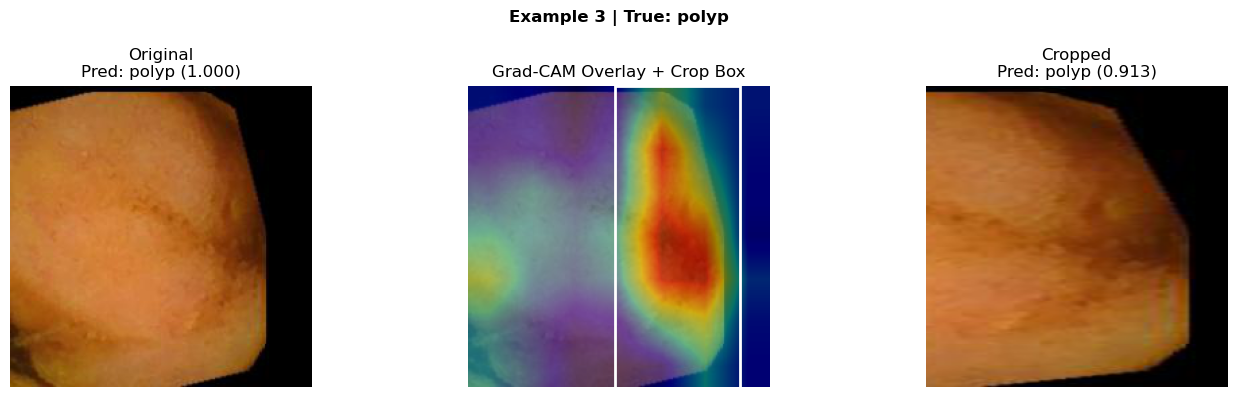

[3] aug_63_131368cc17e44240_28963.jpg
  Original -> class: polyp                     | confidence: 1.0000
  Cropped  -> class: polyp                     | confidence: 0.9131
  Heatmap shape: (224, 224) | min/max: (0.0000, 1.0000)
  Threshold (top 30%): 0.3523
  BBox (x1,y1,x2,y2): (109, 0, 201, 223) | size: 93x224
  Largest component area ratio: 0.2603
  Saved: 03_aug_63_131368cc17e44240_28963_original.png, _heatmap.png, _overlay.png, _cropped.png, _details.txt
----------------------------------------------------------------------------------------------------


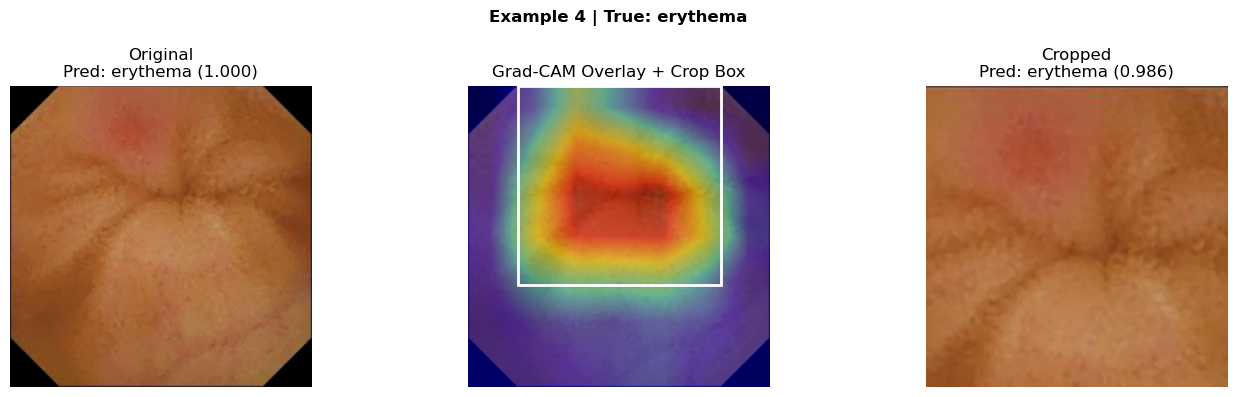

[4] 5e59c7fdb16c4228_26129.jpg
  Original -> class: erythema                  | confidence: 1.0000
  Cropped  -> class: erythema                  | confidence: 0.9860
  Heatmap shape: (224, 224) | min/max: (0.0000, 1.0000)
  Threshold (top 30%): 0.4527
  BBox (x1,y1,x2,y2): (37, 0, 187, 147) | size: 151x148
  Largest component area ratio: 0.3000
  Saved: 04_5e59c7fdb16c4228_26129_original.png, _heatmap.png, _overlay.png, _cropped.png, _details.txt
----------------------------------------------------------------------------------------------------
All outputs saved in: c:\Users\tarun\OneDrive\Desktop\Project-DL\results\gradcam_outputs


In [6]:
# -----------------------------
# Run on a few test images and compare original vs cropped predictions
# -----------------------------
def run_demo(num_images=4, output_dir=OUTPUT_DIR):
    os.makedirs(output_dir, exist_ok=True)
    chosen = random.sample(test_samples, k=min(num_images, len(test_samples)))

    for i, (img_path, true_label) in enumerate(chosen, start=1):
        pil_img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

        # Original prediction
        orig_tensor = eval_tf(pil_img).unsqueeze(0).to(DEVICE)
        pred_cls_orig, conf_orig, pred_idx_orig = predict_with_confidence(model, orig_tensor, idx_to_class)

        # Grad-CAM for predicted class
        heatmap, used_class_idx = grad_cam.generate(orig_tensor, class_idx=pred_idx_orig)
        orig_disp = denormalize_tensor(orig_tensor[0])
        overlay = make_overlay(orig_disp, heatmap, alpha=0.45)

        # Crop from heatmap + prediction on cropped image
        cropped_pil, lcc_mask, crop_stats = crop_from_heatmap(pil_img, heatmap, top_fraction=0.30)
        crop_tensor = eval_tf(cropped_pil).unsqueeze(0).to(DEVICE)
        pred_cls_crop, conf_crop, pred_idx_crop = predict_with_confidence(model, crop_tensor, idx_to_class)

        # Save outputs to folder
        stem = os.path.splitext(os.path.basename(img_path))[0]
        sample_tag = f'{i:02d}_{stem}'

        Image.fromarray((orig_disp * 255).astype(np.uint8)).save(os.path.join(output_dir, f'{sample_tag}_original.png'))
        plt.imsave(os.path.join(output_dir, f'{sample_tag}_heatmap.png'), heatmap, cmap='jet')
        Image.fromarray((overlay * 255).astype(np.uint8)).save(os.path.join(output_dir, f'{sample_tag}_overlay.png'))
        cropped_pil.save(os.path.join(output_dir, f'{sample_tag}_cropped.png'))

        x1, y1, x2, y2 = crop_stats['bbox']
        details = {
            'image_path': img_path,
            'true_class': idx_to_class[true_label],
            'used_cam_class_idx': used_class_idx,
            'used_cam_class_name': idx_to_class[used_class_idx],
            'heatmap_shape': list(heatmap.shape),
            'heatmap_min': float(heatmap.min()),
            'heatmap_max': float(heatmap.max()),
            'threshold_top_30pct': crop_stats['threshold'],
            'top_fraction_pixels': crop_stats['mask_pixels_top_fraction'],
            'largest_component_pixels': crop_stats['mask_pixels_lcc'],
            'largest_component_area_ratio': crop_stats['mask_pixels_lcc'] / float(IMG_SIZE * IMG_SIZE),
            'bbox_xyxy': [x1, y1, x2, y2],
            'bbox_width': crop_stats['bbox_width'],
            'bbox_height': crop_stats['bbox_height'],
            'prediction_original': pred_cls_orig,
            'confidence_original': conf_orig,
            'prediction_cropped': pred_cls_crop,
            'confidence_cropped': conf_crop,
            'confidence_delta_cropped_minus_original': conf_crop - conf_orig,
        }

        with open(os.path.join(output_dir, f'{sample_tag}_details.txt'), 'w', encoding='utf-8') as f:
            for k, v in details.items():
                f.write(f'{k}: {v}\n')

        # Display
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        fig.suptitle(f'Example {i} | True: {idx_to_class[true_label]}', fontsize=12, fontweight='bold')

        axes[0].imshow(orig_disp)
        axes[0].set_title(f'Original\nPred: {pred_cls_orig} ({conf_orig:.3f})')
        axes[0].axis('off')

        axes[1].imshow(overlay)
        rect = plt.Rectangle((x1, y1), x2 - x1 + 1, y2 - y1 + 1, fill=False, edgecolor='white', linewidth=2)
        axes[1].add_patch(rect)
        axes[1].set_title('Grad-CAM Overlay + Crop Box')
        axes[1].axis('off')

        axes[2].imshow(cropped_pil)
        axes[2].set_title(f'Cropped\nPred: {pred_cls_crop} ({conf_crop:.3f})')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        print(f'[{i}] {os.path.basename(img_path)}')
        print(f'  Original -> class: {pred_cls_orig:25s} | confidence: {conf_orig:.4f}')
        print(f'  Cropped  -> class: {pred_cls_crop:25s} | confidence: {conf_crop:.4f}')
        print(f'  Heatmap shape: {heatmap.shape} | min/max: ({heatmap.min():.4f}, {heatmap.max():.4f})')
        print(f'  Threshold (top 30%): {crop_stats["threshold"]:.4f}')
        print(f'  BBox (x1,y1,x2,y2): {crop_stats["bbox"]} | size: {crop_stats["bbox_width"]}x{crop_stats["bbox_height"]}')
        print(f'  Largest component area ratio: {details["largest_component_area_ratio"]:.4f}')
        print(f'  Saved: {sample_tag}_original.png, _heatmap.png, _overlay.png, _cropped.png, _details.txt')
        print('-' * 100)

    print(f'All outputs saved in: {os.path.abspath(output_dir)}')


run_demo(num_images=4, output_dir=OUTPUT_DIR)